# ERP Copilot: Retrieval-Augmented Q&A with Text-to-SQL and Guardrails
**Author:** Atul Iwale · **Project 2 upgrade** of the AEC Fieldwork portfolio

**Business question:** can a project manager ask the ERP a plain-English question, such as *"Is invoice 45 paid?"*, *"How much receivable is pending on Jaipur Metro Viaduct 2?"* or *"What does contract CON00082 say about indemnity?"*, and get a correct answer with the exact records behind it, **without the assistant inventing anything**?

The Copilot combines four parts, each measured separately:
1. **Retrieval (RAG):** find the right records in a knowledge base built from the portfolio's cost, procurement, invoice and contract data.
2. **Intent router:** a classifier that decides whether a question needs a *lookup*, a *calculation* (text-to-SQL), or should be *declined*.
3. **Text-to-SQL:** turns calculation questions into SQL, runs it, and answers from the result.
4. **Guardrails and grounding:** declines off-topic questions and records that don't exist, and checks that every number in an answer comes from a cited source.

**Data:** unchanged copies of the Project 1, 5 (v2), 6 and 7 source tables, plus three evaluation sets: 270 lookup questions, 224 calculation questions and 26 questions that must be declined. All synthetic, patterned on real ERP schemas.

In [1]:
import re, json, sqlite3, os, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, scipy.sparse as sp
from collections import Counter
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
pd.set_option('display.width', 170); pd.set_option('display.max_colwidth', 110)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
DATA = '../data/02_ERP_Copilot_v2.xlsx'
X = {s: pd.read_excel(DATA, sheet_name=s) for s in pd.ExcelFile(DATA).sheet_names}
dp, fcv, dv, po, dcu, inv, dc, fc = (X[k] for k in ['dim_project', 'fact_cost_value', 'dim_vendor', 'fact_purchase_order', 'dim_customer', 'fact_invoice', 'dim_contract', 'fact_clause'])
ev_r, ev_s, ev_o = X['eval_retrieval'], X['eval_sql'], X['eval_out_of_scope']
print({k: len(v) for k, v in X.items()})

{'dim_project': 30, 'dim_cost_code': 25, 'fact_cost_value': 1200, 'dim_vendor': 60, 'fact_purchase_order': 800, 'dim_customer': 80, 'fact_invoice': 1000, 'dim_contract': 200, 'fact_clause': 800, 'eval_retrieval': 270, 'eval_sql': 224, 'eval_out_of_scope': 26, 'data_dictionary': 7}


## 1. Build the knowledge base
Each ERP record becomes one short **document** written in plain language, with its ID and the IDs it links to kept as **metadata**. One record per document is the right chunk size here: records are short, and a lookup answer should cite exactly one record.

In [2]:
pn = dp.set_index('project_id').project_name; vn = dv.set_index('vendor_id'); cn = dcu.set_index('customer_id').customer_name
last_m = fcv.groupby('project_id').period_month.max()
po['days_late'] = (po.actual_delivery_date - po.promised_date).dt.days
cr = lambda v: f'Rs {v/1e7:,.2f} crore'
def cpi_latest(p):
    d = fcv[(fcv.project_id == p) & (fcv.period_month == last_m[p])]; return round(d.earned_value.sum() / d.actual_cost.sum(), 3)
docs = []
for r in dp.itertuples():
    p_po = po[po.project_id == r.project_id]; p_inv = inv[(inv.project_id == r.project_id) & inv.payment_date.isna()]
    ar, ap = p_inv[p_inv.type == 'AR'].amount.sum(), p_inv[p_inv.type == 'AP'].amount.sum()
    docs.append(dict(doc_id=f'PRJ:{r.project_id}', kind='project', meta=[r.project_id],
        text=f"Project overview for {r.project_id} {r.project_name} (region {r.region}). Contract value {cr(r.contract_value)}; planned {r.start_date:%d %b %Y} to {r.end_date:%d %b %Y}. "
             f"Latest cost performance ({last_m[r.project_id]:%b %Y}): CPI {cpi_latest(r.project_id)}. Purchase orders: {len(p_po)}, of which {(p_po.days_late > 0).sum()} were delivered late. "
             f"Unpaid receivables {cr(ar)}; unpaid payables {cr(ap)}."))
for r in po.itertuples():
    st = f'delivered {r.days_late} days late' if r.days_late > 0 else ('delivered on time' if r.days_late == 0 else f'delivered {-r.days_late} days early')
    docs.append(dict(doc_id=f'PO:{r.po_id}', kind='purchase_order', meta=[r.po_id, r.project_id, r.vendor_id],
        text=f"Purchase order {r.po_id} for project {r.project_id} {pn[r.project_id]}. Vendor {vn.vendor_name[r.vendor_id]} ({vn.vendor_category[r.vendor_id]}). Item {r.item_description}, value {cr(r.po_value)}. "
             f"Ordered {r.order_date:%d %b %Y}, promised {r.promised_date:%d %b %Y}, {st} on {r.actual_delivery_date:%d %b %Y}."))
for r in inv.itertuples():
    party = cn.get(r.party_id) if r.type == 'AR' else vn.vendor_name.get(r.party_id)
    paid = f'paid on {r.payment_date:%d %b %Y}' if pd.notna(r.payment_date) else 'not yet paid'
    docs.append(dict(doc_id=f'INV:{r.invoice_id}', kind='invoice', meta=[r.invoice_id, r.project_id, r.party_id],
        text=f"Invoice {r.invoice_id} is an {'accounts receivable (customer)' if r.type == 'AR' else 'accounts payable (vendor)'} invoice for project {r.project_id} {pn[r.project_id]}, "
             f"{'customer' if r.type == 'AR' else 'vendor'} {party}. Amount {cr(r.amount)}, dated {r.invoice_date:%d %b %Y}, due {r.due_date:%d %b %Y}. Status {r.status}; {paid}."))
dcn = dc.set_index('contract_id')
for r in fc.itertuples():
    c = dcn.loc[r.contract_id]
    docs.append(dict(doc_id=f'CLA:{r.clause_id}', kind='clause', meta=[r.clause_id, r.contract_id], ctype=r.clause_type,
        text=f"Contract {r.contract_id} {c.contract_name} with {c.counterparty}. {r.clause_type} clause ({r.clause_id}), risk rating {r.risk_category}: {r.clause_text}"))
kb = pd.DataFrame(docs); print(kb.kind.value_counts().to_dict())
for k in ['project', 'purchase_order', 'invoice', 'clause']: print('\n', kb[kb.kind == k].text.iloc[0][:300])

{'invoice': 1000, 'purchase_order': 800, 'clause': 800, 'project': 30}

 Project overview for PRJ001 Mumbai Metro Viaduct 1 (region North). Contract value Rs 606.90 crore; planned 26 May 2025 to 24 Jun 2026. Latest cost performance (Sep 2026): CPI 0.547. Purchase orders: 27, of which 27 were delivered late. Unpaid receivables Rs 49.71 crore; unpaid payables Rs 0.00 crore

 Purchase order PO000001 for project PRJ001 Mumbai Metro Viaduct 1. Vendor Apex Ready Mix Pvt Ltd (RMC). Item TMT rebar Fe500D, value Rs 3.50 crore. Ordered 29 Nov 2025, promised 13 Dec 2025, delivered 32 days late on 14 Jan 2026.

 Invoice INV000001 is an accounts receivable (customer) invoice for project PRJ001 Mumbai Metro Viaduct 1, customer Lotus Industries 4 Ltd. Amount Rs 2.37 crore, dated 13 Jun 2025, due 28 Jul 2025. Status Disputed; not yet paid.

 Contract CON00001 Works Agreement 1 with Shree Cements Pvt Ltd. Indemnity clause (CLA000001), risk rating High: The Contractor agrees to fully indemnify the Compa

## 2. Query normalisation
Users write IDs in many ways: *PO 85*, *purchase order 85*, *invoice no 45*, *inv 45*. They also make typos. Before retrieval every query is:
1. **Spell-corrected** against the knowledge-base vocabulary (a word of 5+ letters that isn't in the vocabulary is swapped for a known word one edit away, e.g. *purcahse* → *purchase*).
2. **ID-normalised** to the canonical form used in the records (*po 85* → `po000085`).
3. **Tokenised**, dropping common stop words.

In [3]:
STOP = set('a an the of to in on for and or is are was were be been by with at from as it its this that what which who whom how many much me my our we us you your show tell give about did does do has have had any all than please'.split())
VOCAB_WORDS = Counter(w for t in kb.text for w in re.findall(r'[a-z]+', t.lower()))
KEEP = set(w for t in pd.concat([ev_s[ev_s.split == 'train'].question, ev_o[ev_o.split == 'train'].question]) for w in re.findall(r'[a-z]+', t.lower()))
KEEP |= {'worth', 'pending', 'receivable', 'payable', 'lateness', 'typical', 'risky', 'jobs', 'lower', 'owed', 'owing', 'supplied'}
def one_edit(a, b):
    if abs(len(a) - len(b)) > 1: return False
    if len(a) == len(b):
        d = [i for i in range(len(a)) if a[i] != b[i]]
        return len(d) == 1 or (len(d) == 2 and d[1] == d[0] + 1 and a[d[0]] == b[d[1]] and a[d[1]] == b[d[0]])
    s, l = (a, b) if len(a) < len(b) else (b, a)
    return any(l[:i] + l[i+1:] == s for i in range(len(l)))
def spell(q):
    out = []
    for w in re.findall(r'[A-Za-z]+|[^A-Za-z]+', q):
        lw = w.lower()
        if w.isalpha() and len(lw) >= 5 and lw not in VOCAB_WORDS and lw not in KEEP:
            c = [v for v in VOCAB_WORDS if len(v) >= 4 and one_edit(lw, v)]
            if c: w = max(c, key=lambda v: (VOCAB_WORDS[v], v))
        out.append(w)
    return ''.join(out)
def norm_ids(t):
    t = t.lower()
    t = re.sub(r'\b(?:purchase\s+order|po)\s*(?:no\.?\s*|number\s*)?0*(\d{1,6})\b', lambda m: f'po{int(m.group(1)):06d}', t)
    t = re.sub(r'\b(?:invoice|inv)\s*(?:no\.?\s*|number\s*)?0*(\d{1,6})\b', lambda m: f'inv{int(m.group(1)):06d}', t)
    t = re.sub(r'\b(?:project\s+)?prj\s*0*(\d{1,3})\b', lambda m: f'prj{int(m.group(1)):03d}', t)
    t = re.sub(r'\b(?:contract\s+)?con\s*0*(\d{1,5})\b', lambda m: f'con{int(m.group(1)):05d}', t)
    return t
def tok(t): return [w for w in re.findall(r'[a-z0-9]+', norm_ids(t)) if w not in STOP and len(w) > 1]
def prep(q): return norm_ids(spell(q))
for q in ['who supplied purcahse order 85?', 'has invoice no 45 been settled?', 'Show the indemnity terms of CON 82']: print(f'{q!r:45} -> {prep(q)!r}')

'who supplied purcahse order 85?'             -> 'who supplied po000085?'
'has invoice no 45 been settled?'             -> 'has inv000045 been settled?'
'Show the indemnity terms of CON 82'          -> 'show the indemnity terms of con00082'


## 3. Retrieval methods
Four ways to rank documents for a query, all built from scratch so the web app can run exactly the same maths:

In [4]:
T = [tok(t) for t in kb.text]; N = len(T)
vocab = {}
for t in T:
    for w in set(t): vocab[w] = vocab.get(w, 0) + 1
widx = {w: i for i, w in enumerate(vocab)}
rows, cols, vals = [], [], []
for i, t in enumerate(T):
    for w, c in Counter(t).items(): rows.append(i); cols.append(widx[w]); vals.append(c)
C = sp.csr_matrix((vals, (rows, cols)), shape=(N, len(vocab)), dtype=float); Cc = C.tocsc()
df_ = np.array([vocab[w] for w in vocab]); dlen = np.array([len(t) for t in T]); avgdl = dlen.mean()
IDF_BM = np.log(1 + (N - df_ + .5) / (df_ + .5)); IDF_TF = np.log((1 + N) / (1 + df_)) + 1
K1, B = 1.5, 0.75
def bm25(qt):
    s = np.zeros(N)
    for w in set(qt):
        if w in widx:
            j = widx[w]; f = Cc[:, j].toarray().ravel(); s += IDF_BM[j] * f * (K1 + 1) / (f + K1 * (1 - B + B * dlen / avgdl))
    return s
Tm = C.multiply(IDF_TF).tocsr(); Tm = sp.diags(1 / np.sqrt(Tm.multiply(Tm).sum(1).A.ravel())) @ Tm
def qvec(qt):
    v = np.zeros(len(vocab))
    for w, c in Counter(qt).items():
        if w in widx: v[widx[w]] = c * IDF_TF[widx[w]]
    n = np.linalg.norm(v); return v / n if n else v
def tfidf(qt): return Tm @ qvec(qt)
svd = TruncatedSVD(128, random_state=42).fit(Tm); D = svd.transform(Tm); D /= np.linalg.norm(D, axis=1, keepdims=True) + 1e-12
def lsa(qt):
    z = svd.transform(qvec(qt)[None])[0]; n = np.linalg.norm(z); return D @ (z / n if n else z)
def rrf(*scores, k=60):
    s = np.zeros(N)
    for sc in scores: r = np.argsort(-sc)[:100]; s[r] += 1 / (k + np.arange(1, 101))
    return s
print(f'{N} documents, {len(vocab)} distinct terms, LSA explains {svd.explained_variance_ratio_.sum():.0%} of TF-IDF variance with 128 dimensions')

2630 documents, 3582 distinct terms, LSA explains 72% of TF-IDF variance with 128 dimensions


- **BM25:** the standard keyword ranking used by search engines; rewards rare, matching words and adjusts for document length.
- **TF-IDF cosine:** similarity of weighted word vectors.
- **LSA vectors:** dense 128-dimension "semantic" vectors (truncated SVD of TF-IDF), the classic form of vector search. Pre-trained neural embeddings were not available offline, so LSA plays that role here.
- **Hybrid (RRF):** reciprocal rank fusion of BM25 and LSA, a common way to combine keyword and vector search.

## 4. Entity-aware retrieval (final design)
ERP questions are mostly about **specific records**. So the final retriever first extracts entities (IDs, and names of projects, vendors, customers and contracts), **filters** to documents linked to them, then ranks with BM25, boosting the document whose own ID was asked for and clauses of the type mentioned.

In [5]:
NAMES = sorted([(n.lower(), p.lower()) for p, n in zip(dp.project_id, dp.project_name)] + [(n.lower(), v.lower()) for v, n in zip(dv.vendor_id, dv.vendor_name)] +
               [(n.lower(), c.lower()) for c, n in zip(dcu.customer_id, dcu.customer_name)] + [(n.lower(), c.lower()) for c, n in zip(dc.contract_id, dc.contract_name)], key=lambda x: -len(x[0]))
CTYPES = {'indemnity': 'Indemnity', 'liability': 'Liability Cap', 'payment': 'Payment Terms', 'renewal': 'Auto-Renewal', 'renew': 'Auto-Renewal',
          'force majeure': 'Force Majeure', 'majeure': 'Force Majeure', 'termination': 'Termination', 'terminate': 'Termination'}
META = [set(m.lower() for m in ms) for ms in kb.meta]; OWN = [d.split(':')[1].lower() for d in kb.doc_id]; CT = kb.get('ctype').fillna('').values
KNOWN = set(o for o in OWN) | set(dv.vendor_id.str.lower()) | set(dcu.customer_id.str.lower()) | set(dc.contract_id.str.lower())
ID_RE = r'\b(?:prj\d{3}|po\d{6}|inv\d{6}|con\d{5}|v\d{3}|cus\d{4})\b'
def entities(q):
    ql = prep(q); ids = set(re.findall(ID_RE, ql)); names = set()
    for n, k in NAMES:
        if re.search(r'(?<![\w])' + re.escape(n) + r'(?![\w])', ql): names.add(k); ql = ql.replace(n, ' ')
    return ids | names, ids - KNOWN
def clause_type(q):
    ql = q.lower(); return next((v for k, v in CTYPES.items() if k in ql), None)
def topk(s, k):
    # deterministic ranking: score rounded to 6 dp, ties broken by lower index (same rule as the browser app)
    return np.lexsort((np.arange(len(s)), -np.round(s, 6)))[:k]
def entity_retrieve(q):
    e, _ = entities(q); s = bm25(tok(prep(q)))
    if e:
        s = s + np.array([1000.0 if (m & e) else 0.0 for m in META]) + np.array([500.0 if o in e else 0.0 for o in OWN])
    ct = clause_type(q)
    if ct: s = s + np.where(CT == ct, 200.0, 0.0)
    return s
METHODS = {'BM25': lambda q: bm25(tok(prep(q))), 'TF-IDF cosine': lambda q: tfidf(tok(prep(q))), 'LSA vectors': lambda q: lsa(tok(prep(q))),
           'Hybrid (BM25 + LSA, RRF)': lambda q: rrf(bm25(tok(prep(q))), lsa(tok(prep(q)))), 'Entity-aware BM25 (final)': entity_retrieve}
ids = kb.doc_id.values; rows = []
for name, fn in METHODS.items():
    for r in ev_r.itertuples():
        top = ids[topk(fn(r.question), 10)]; g = set(r.gold_doc_id.split(';'))
        rank = next((i + 1 for i, d in enumerate(top) if d in g), 99)
        rows.append(dict(method=name, style=r.style.replace('+typo', ''), typo='+typo' in r.style, doc_type=r.doc_type, rank=rank))
rr = pd.DataFrame(rows)
ret_res = rr.groupby('method', sort=False).agg(**{'Recall@1': ('rank', lambda s: (s == 1).mean()), 'Recall@3': ('rank', lambda s: (s <= 3).mean()),
          'Recall@5': ('rank', lambda s: (s <= 5).mean()), 'MRR': ('rank', lambda s: (1 / s).mean())}).round(3)
ret_res

,Recall@1,Recall@3,Recall@5,MRR
method,,,,
BM25,0.878,0.893,0.893,0.886
TF-IDF cosine,0.826,0.848,0.859,0.841
LSA vectors,0.352,0.430,0.441,0.401
"Hybrid (BM25 + LSA, RRF)",0.463,0.519,0.574,0.515
Entity-aware BM25 (final),1.000,1.000,1.000,1.000


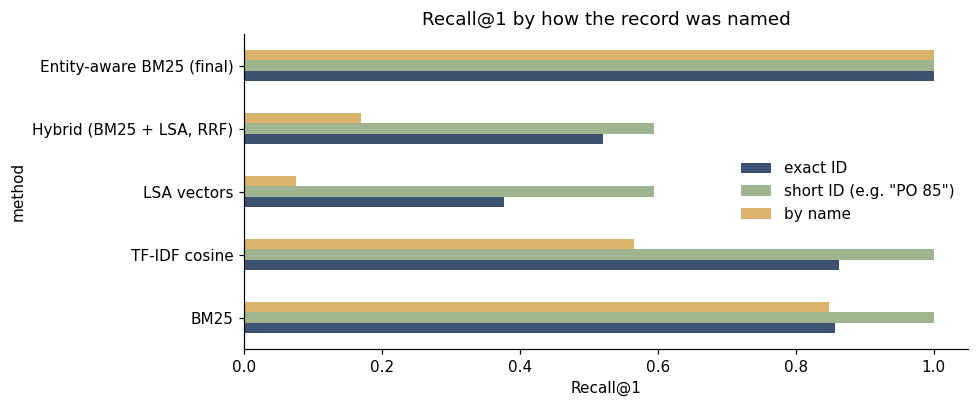

Entity-aware Recall@1 on questions with typos: 1.0


In [6]:
fig, ax = plt.subplots(figsize=(9, 3.8))
piv = rr.assign(hit=rr['rank'] == 1).groupby(['method', 'style'], sort=False).hit.mean().unstack()[['id', 'short_id', 'name']]
piv.plot.barh(ax=ax, color=['#3f5170', '#9fb58f', '#d9b36b']); ax.set_xlabel('Recall@1'); ax.set_title('Recall@1 by how the record was named')
ax.legend(['exact ID', 'short ID (e.g. "PO 85")', 'by name'], frameon=False); plt.tight_layout(); plt.show()
print('Entity-aware Recall@1 on questions with typos:', round((rr[(rr.method == 'Entity-aware BM25 (final)') & rr.typo]['rank'] == 1).mean(), 3))

**Reading the results**
- **Vector search alone fails on ERP data.** LSA vectors capture topics ("an invoice about payment") but not identity: *INV000045* and *INV000046* look almost identical in a semantic space. This is why production RAG systems over business data combine vectors with keyword or metadata search.
- **BM25 is strong** because IDs and names are rare, exact words, and normalising *PO 85* to `po000085` is what lets it work on short IDs.
- **Entity-aware BM25 is best:** filtering by extracted entities, then ranking, finds the right record almost every time, including questions with typos.

## 5. Intent router
A classifier decides what kind of question it is: a **lookup** (retrieval), one of **eight calculation intents** (text-to-SQL), or **out of scope**. Entities and numbers are replaced with placeholders first (`<project>`, `<num>`, …) so the router learns the *shape* of a question, not the specific names.

It is trained on one set of question wordings and tested on **different wordings it has never seen**.

In [7]:
LEX = [(r'\b(pending|outstanding|overdue|unpaid|owe|owed|owing|due)\b', 'unpaid'), (r'\b(receivables?|ar)\b', 'receivable'), (r'\b(payables?|ap)\b', 'payable'),
       (r'\b(worth|value|amount|big|size)\b', 'value'), (r'\b(late|lateness|delay|delays|delayed)\b', 'late'), (r'\b(average|mean|typical|typically)\b', 'average'),
       (r'\bcost performance( index)?\b', 'cpi'), (r'\b(risky|risk)\b', 'risk'), (r'\b(jobs|projects)\b', 'projects'), (r'\b(lower|less|under|below)\b', 'below'),
       (r'\b(count|number)\b', 'many'), (r'\b(pos|purchase orders?)\b', 'po')]
def mask(q):
    ql = q.lower()
    for pat, rep_ in LEX: ql = re.sub(pat, rep_, ql)
    ql = prep(ql)
    for n, k in NAMES:
        if n in ql: ql = ql.replace(n, ' <' + ('project' if k.startswith('prj') else 'vendor' if re.match(r'v\d', k) else 'customer' if k.startswith('cus') else 'contract') + '> ')
    ql = re.sub(r'\bprj\d{3}\b', ' <project> ', ql); ql = re.sub(r'\bpo\d{6}\b', ' <po> ', ql); ql = re.sub(r'\binv\d{6}\b', ' <invoice> ', ql)
    ql = re.sub(r'\bcon\d{5}\b', ' <contract> ', ql); ql = re.sub(r'\b\d+(\.\d+)?\b', ' <num> ', ql)
    return ql
def feats(q):
    w = [x for x in re.findall(r'<[a-z]+>|[a-z]+', mask(q)) if x not in STOP or x in ('how', 'many', 'much', 'which', 'what')]
    return set(w) | {a + ' ' + b for a, b in zip(w, w[1:])}
r_tr = ev_r.sample(frac=.5, random_state=42)
router_train = pd.concat([ev_s[ev_s.split == 'train'][['question', 'intent']], r_tr.assign(intent='lookup')[['question', 'intent']],
                          ev_o[ev_o.split == 'train'].assign(intent='out_of_scope')[['question', 'intent']]])
router_test = pd.concat([ev_s[ev_s.split == 'test'][['question', 'intent']], ev_r.drop(r_tr.index).assign(intent='lookup')[['question', 'intent']],
                         ev_o[ev_o.split == 'test'].assign(intent='out_of_scope')[['question', 'intent']]])
FV = sorted(set().union(*[feats(q) for q in router_train.question])); fidx = {f: i for i, f in enumerate(FV)}
def fmat(qs):
    r, c = [], []
    for i, q in enumerate(qs):
        for f in feats(q):
            if f in fidx: r.append(i); c.append(fidx[f])
    return sp.csr_matrix((np.ones(len(r)), (r, c)), shape=(len(qs), len(FV)))
router = LogisticRegression(C=10, max_iter=5000, class_weight='balanced').fit(fmat(router_train.question.tolist()), router_train.intent)
pred = router.predict(fmat(router_test.question.tolist()))
print('Domain lexicon maps synonyms before routing, e.g.', mask('How much receivable is pending for PRJ011?'), '|', mask('What is PRJ004 worth?'))
print(f'Router: {len(router_train)} training questions, {len(router_test)} test questions with unseen wording, {len(FV)} features')
print('Test accuracy:', round(accuracy_score(router_test.intent, pred), 3))
print(classification_report(router_test.intent, pred, zero_division=0))

Domain lexicon maps synonyms before routing, e.g. how much receivable is unpaid for  <project> ? | what is  <project>  value?
Router: 291 training questions, 229 test questions with unseen wording, 253 features
Test accuracy: 0.921
                    precision    recall  f1-score   support

    ap_outstanding       1.00      1.00      1.00        10
    ar_outstanding       0.91      1.00      0.95        10
    contract_value       1.00      0.30      0.46        10
 high_risk_clauses       1.00      1.00      1.00        10
     late_po_count       1.00      1.00      1.00        10
            lookup       0.89      1.00      0.94       135
      out_of_scope       1.00      0.57      0.73        14
       project_cpi       0.83      0.50      0.62        10
projects_below_cpi       1.00      1.00      1.00        10
  vendor_avg_delay       1.00      1.00      1.00        10

          accuracy                           0.92       229
         macro avg       0.96      0.84      0

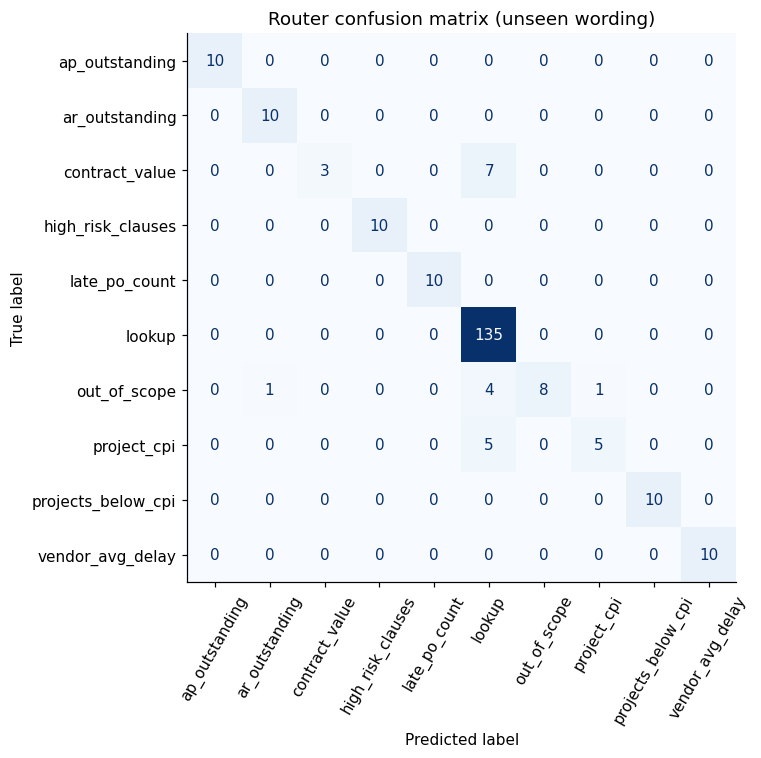

In [8]:
labs = sorted(router_test.intent.unique())
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(confusion_matrix(router_test.intent, pred, labels=labs), display_labels=labs).plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=60)
ax.set_title('Router confusion matrix (unseen wording)'); plt.tight_layout(); plt.show()

## 6. Slot filling and text-to-SQL
For a calculation intent, the Copilot fills the slots (project, vendor, contract, threshold), writes the **SQL**, runs it on an SQLite copy of the ERP tables, and answers from the result. The SQL is shown to the user, so the calculation can be checked.

In [9]:
con = sqlite3.connect(':memory:')
for name, d in [('dim_project', dp), ('fact_cost_value', fcv), ('dim_vendor', dv), ('fact_purchase_order', po.drop(columns='days_late')), ('fact_invoice', inv), ('fact_clause', fc)]:
    d2 = d.copy()
    for c in d2.columns:
        if pd.api.types.is_datetime64_any_dtype(d2[c]): d2[c] = d2[c].dt.strftime('%Y-%m-%d')
    d2.to_sql(name, con, index=False)
VEND = sorted(set((n.lower(), n) for n in dv.vendor_name), key=lambda x: -len(x[0]))
print(f'Vendor master check: {dv.vendor_name.nunique()} vendor names map to {dv.vendor_id.nunique()} vendor IDs, so each supplier is registered twice. The SQL groups by vendor name so the full delivery history is counted.')
def slots(q):
    e, _ = entities(q); ql = prep(q)
    proj = next((x.upper() for x in e if x.startswith('prj')), None); cont = next((x.upper() for x in e if x.startswith('con')), None)
    vend = next((n for l, n in VEND if l in ql), None); num = re.search(r'(\d+\.\d+|\b[01]\b)', re.sub(ID_RE, ' ', ql))
    return dict(project=proj, vendor=vend, contract=cont, threshold=float(num.group(1)) if num else None)
SQL = {
 'ar_outstanding': ("SELECT COALESCE(SUM(amount),0), COUNT(*), GROUP_CONCAT(invoice_id) FROM fact_invoice WHERE type='AR' AND payment_date IS NULL AND project_id=:project", 'project'),
 'ap_outstanding': ("SELECT COALESCE(SUM(amount),0), COUNT(*), GROUP_CONCAT(invoice_id) FROM fact_invoice WHERE type='AP' AND payment_date IS NULL AND project_id=:project", 'project'),
 'late_po_count': ("SELECT COUNT(*), COUNT(*), GROUP_CONCAT(po_id) FROM fact_purchase_order WHERE project_id=:project AND julianday(actual_delivery_date) > julianday(promised_date)", 'project'),
 'vendor_avg_delay': ("SELECT COALESCE(ROUND(AVG(julianday(p.actual_delivery_date)-julianday(p.promised_date)),1),0), COUNT(*), GROUP_CONCAT(p.po_id) FROM fact_purchase_order p JOIN dim_vendor v ON v.vendor_id=p.vendor_id "
                      "WHERE v.vendor_name=:vendor AND julianday(p.actual_delivery_date) > julianday(p.promised_date)", 'vendor'),
 'project_cpi': ("SELECT ROUND(SUM(earned_value)*1.0/SUM(actual_cost),3), COUNT(*), GROUP_CONCAT(row_id) FROM fact_cost_value WHERE project_id=:project "
                 "AND period_month=(SELECT MAX(period_month) FROM fact_cost_value WHERE project_id=:project)", 'project'),
 'projects_below_cpi': ("WITH last AS (SELECT project_id, MAX(period_month) m FROM fact_cost_value GROUP BY project_id), cpi AS (SELECT f.project_id, SUM(earned_value)*1.0/SUM(actual_cost) c "
                        "FROM fact_cost_value f JOIN last l ON l.project_id=f.project_id AND f.period_month=l.m GROUP BY f.project_id) SELECT GROUP_CONCAT(project_id), COUNT(*), GROUP_CONCAT(project_id) "
                        "FROM (SELECT project_id FROM cpi WHERE ROUND(c,3) < :threshold ORDER BY project_id)", 'threshold'),
 'contract_value': ("SELECT contract_value, 1, project_id FROM dim_project WHERE project_id=:project", 'project'),
 'high_risk_clauses': ("SELECT COUNT(*), COUNT(*), GROUP_CONCAT(clause_id) FROM fact_clause WHERE contract_id=:contract AND risk_category='High'", 'contract'),
}
def run_sql(intent, s):
    sql, need = SQL[intent]
    if s[need] is None: return None, sql, None
    val, n, src = con.execute(sql, s).fetchone(); return val, sql, (sorted(src.split(',')) if src else [])   # sorted so source lists are stable
def same(intent, a, b):   # SQLite and pandas round .x5 differently, so averages may differ by 0.1 in the last digit
    if intent == 'projects_below_cpi' or a in ('None', '') or b in ('None', ''): return a == b
    return abs(float(a) - float(b)) <= (0.1 if intent == 'vendor_avg_delay' else 1e-9)
def canon(intent, v):
    if intent == 'projects_below_cpi': return ','.join(sorted(v.split(','))) if v else ''
    return str(round(float(v), 3)) if v is not None else 'None'
res_sql = []
for r in ev_s.itertuples():
    s = slots(r.question); val, sql, src = run_sql(r.intent, s)
    gold = ','.join(sorted(eval(r.gold_answer))) if r.intent == 'projects_below_cpi' else str(round(float(r.gold_answer), 3))
    res_sql.append(dict(split=r.split, intent=r.intent, slot_ok=(s.get(SQL[r.intent][1]) is not None), exec_ok=same(r.intent, canon(r.intent, val), gold)))
res_sql = pd.DataFrame(res_sql)
print('Given the correct intent, slot filling + SQL execution matches the gold answer on', f"{res_sql.exec_ok.mean():.1%}", 'of', len(res_sql), 'questions')
res_sql.groupby('intent')[['slot_ok', 'exec_ok']].mean().round(3)

Vendor master check: 30 vendor names map to 60 vendor IDs, so each supplier is registered twice. The SQL groups by vendor name so the full delivery history is counted.
Given the correct intent, slot filling + SQL execution matches the gold answer on 100.0% of 224 questions


,slot_ok,exec_ok
intent,,
ap_outstanding,1.0,1.0
ar_outstanding,1.0,1.0
contract_value,1.0,1.0
high_risk_clauses,1.0,1.0
late_po_count,1.0,1.0
project_cpi,1.0,1.0
projects_below_cpi,1.0,1.0
vendor_avg_delay,1.0,1.0


## 7. Guardrails
The Copilot must **decline** rather than guess. It declines when:
1. the router says the question is **out of scope** (weather, news, general knowledge);
2. the question names an ID that **does not exist** in the data (e.g. *INV009999*);
3. a lookup question names **no recognisable record** at all (e.g. a project name that isn't in the portfolio);
4. a calculation is missing a required slot (it asks for it instead of guessing).

In [10]:
def answer_plan(q):
    e, unknown = entities(q)
    if unknown: return dict(route='decline', reason=f"I couldn't find {', '.join(sorted(u.upper() for u in unknown))} in the portfolio data.")
    intent = router.predict(fmat([q]))[0]
    if intent == 'out_of_scope': return dict(route='decline', reason='That question is outside the portfolio ERP data, so I will not guess.')
    if intent == 'lookup':
        if not e: return dict(route='decline', reason="I couldn't identify a project, purchase order, invoice or contract in your question.")
        return dict(route='lookup', intent=intent)
    s = slots(q); need = SQL[intent][1]
    if s[need] is None: return dict(route='clarify', intent=intent, reason=f'Which {need} do you mean?')
    return dict(route='sql', intent=intent, slots=s)
in_scope = pd.concat([router_test[router_test.intent != 'out_of_scope'].question, ev_o[ev_o.kind == 'not_in_data'].question.iloc[:0]])
oos_all = ev_o[ev_o.split == 'test']
dec_oos = [answer_plan(q)['route'] == 'decline' for q in oos_all.question]
dec_in = [answer_plan(q)['route'] in ('decline', 'clarify') for q in in_scope]
print(f'Correctly declined: {sum(dec_oos)} of {len(dec_oos)} off-topic / not-in-data test questions ({np.mean(dec_oos):.0%})')
print(f'Wrongly declined: {sum(dec_in)} of {len(dec_in)} in-scope test questions ({np.mean(dec_in):.1%})')
pd.DataFrame({'question': oos_all.question, 'kind': oos_all.kind, 'Copilot': [answer_plan(q).get('reason', answer_plan(q)['route']) for q in oos_all.question]})

Correctly declined: 14 of 14 off-topic / not-in-data test questions (100%)
Wrongly declined: 0 of 215 in-scope test questions (0.0%)


,question,kind,Copilot
12,Will it rain in Mumbai tomorrow?,off_topic,"That question is outside the portfolio ERP data, so I will not guess."
13,Who is the CEO of Tata Steel?,off_topic,"That question is outside the portfolio ERP data, so I will not guess."
14,Explain quantum computing,off_topic,"That question is outside the portfolio ERP data, so I will not guess."
15,What is the best smartphone to buy?,off_topic,"That question is outside the portfolio ERP data, so I will not guess."
16,Give me a recipe for biryani,off_topic,"That question is outside the portfolio ERP data, so I will not guess."
17,What time is it in London?,off_topic,"That question is outside the portfolio ERP data, so I will not guess."
18,Summarise the news today,off_topic,"That question is outside the portfolio ERP data, so I will not guess."
19,Who wrote the Ramayana?,off_topic,"That question is outside the portfolio ERP data, so I will not guess."
20,What is the latest CPI of PRJ099?,not_in_data,I couldn't find PRJ099 in the portfolio data.
21,Is invoice INV009999 paid?,not_in_data,I couldn't find INV009999 in the portfolio data.


## 8. Grounded answers with citations
Answers are composed **only** from retrieved records or SQL results, and every answer cites its sources. An automatic **groundedness check** extracts every number from each answer and confirms it appears in the cited records or the SQL result, so a hallucinated figure would fail the check.

In [11]:
DOC = dict(zip(kb.doc_id, kb.text))
def fmt_val(intent, val):
    if intent in ('ar_outstanding', 'ap_outstanding', 'contract_value'): return cr(val)
    if intent == 'vendor_avg_delay': return f'{val} days'
    return str(val)
TEMPL = {'ar_outstanding': 'Unpaid receivables on {project} {pname}: {v} across {n} invoice(s).', 'ap_outstanding': 'Unpaid payables on {project} {pname}: {v} across {n} invoice(s).',
         'late_po_count': '{project} {pname} has {v} purchase orders delivered late.', 'vendor_avg_delay': '{vendor} delivers {v} late on average, across {n} late purchase order(s).',
         'project_cpi': 'The latest CPI of {project} {pname} is {v}.', 'projects_below_cpi': '{n} project(s) have a latest CPI below {threshold}: {v}.',
         'contract_value': 'The contract value of {project} {pname} is {v}.', 'high_risk_clauses': '{contract} has {v} clause(s) rated High risk.'}
def ask(q):
    plan = answer_plan(q)
    if plan['route'] in ('decline', 'clarify'): return dict(route=plan['route'], answer=plan['reason'], sources=[], evidence=q)   # a decline may only repeat what the user typed
    if plan['route'] == 'sql':
        s = plan['slots']; val, sql, src = run_sql(plan['intent'], s)
        if plan['intent'] == 'vendor_avg_delay' and not src:
            return dict(route='sql', answer=f"{s['vendor']} has no late deliveries on record.", sql=sql, sources=[], evidence=s['vendor'])
        txt = TEMPL[plan['intent']].format(v=fmt_val(plan['intent'], val) if val not in (None, '') else 'none', n=len(src or []), pname=pn.get(s['project'] or '', ''), **s)
        ev = f"{fmt_val(plan['intent'], val) if val not in (None, '') else ''} {len(src or [])} " + ' '.join(str(x) for x in s.values()) + ' ' + ' '.join(DOC.get(f'PRJ:{s["project"]}', '').split()[:12])
        return dict(route='sql', answer=txt, sql=sql, sources=(src or [])[:12], evidence=ev)
    sc = entity_retrieve(q); top = ids[topk(sc, 3)]
    return dict(route='lookup', answer=(lead(top[0]) + ' ' + DOC[top[0]]).strip(), sources=list(top), evidence=' '.join(DOC[t] for t in top))
def lead(doc_id):
    kind, rid = doc_id.split(':')
    if kind == 'INV':
        r = inv.set_index('invoice_id').loc[rid]
        return f"{rid}: {'paid on ' + format(r.payment_date, '%d %b %Y') if pd.notna(r.payment_date) else 'not yet paid (status ' + r.status + ')'}."
    if kind == 'PO':
        r = po.set_index('po_id').loc[rid]; d = r.days_late
        return f"{rid} from {vn.vendor_name[r.vendor_id]}: {'delivered ' + str(d) + ' days late' if d > 0 else 'delivered on time or early'}."
    if kind == 'CLA':
        r = fc.set_index('clause_id').loc[rid]; return f"{r.contract_id}, {r.clause_type} clause (risk rating {r.risk_category}):"
    return ''
NUM = r'\d[\d,]*\.?\d*'
def grounded(a):
    nums = [n.replace(',', '').rstrip('.') for n in re.findall(NUM, a['answer'])]
    ev = set(n.replace(',', '').rstrip('.') for n in re.findall(NUM, a['evidence'] + ' ' + ' '.join(a['sources'])))
    return all(n in ev for n in nums)
all_q = pd.concat([ev_r.question, ev_s.question, ev_o.question]).tolist()
answers = [ask(q) for q in all_q]
print(f'Answers generated: {len(answers)} | every number traceable to a cited source: {np.mean([grounded(a) for a in answers]):.1%}')
for q in ['Is invoice 45 paid?', 'How much receivable is pending for Jaipur Metro Viaduct 2?', 'What does contract CON00082 say about indemnity?', 'Who is the CEO of Tata Steel?']:
    a = ask(q); print(f'\nQ: {q}\n[{a["route"]}] {a["answer"][:260]}\nSources: {a["sources"][:5]}')

Answers generated: 520 | every number traceable to a cited source: 100.0%

Q: Is invoice 45 paid?
[lookup] INV000045: paid on 13 Feb 2025. Invoice INV000045 is an accounts receivable (customer) invoice for project PRJ015 Surat Hospital Campus 2, customer Zenith Hospitals 69 Ltd. Amount Rs 2.40 crore, dated 19 Dec 2024, due 02 Feb 2025. Status Paid; paid on 13 Feb 2
Sources: ['INV:INV000045', 'INV:INV000002', 'INV:INV000012']

Q: How much receivable is pending for Jaipur Metro Viaduct 2?
[sql] Unpaid receivables on PRJ011 Jaipur Metro Viaduct 2: Rs 40.24 crore across 33 invoice(s).
Sources: ['INV000011', 'INV000041', 'INV000071', 'INV000101', 'INV000131']

Q: What does contract CON00082 say about indemnity?
[lookup] CON00082, Indemnity clause (risk rating Medium): Contract CON00082 Supply Agreement 82 with Omkar MEP Systems Pvt Ltd. Indemnity clause (CLA000328), risk rating Medium: Save as otherwise expressly provided herein, the Contractor shall indemnify, defend and hol
Sources: ['CLA

## 9. End-to-end accuracy

In [12]:
def e2e_ok(q, kind, gold):
    a = ask(q)
    if kind == 'decline': return a['route'] == 'decline'
    return a['route'] == 'lookup' and bool(set(a['sources'][:1]) & set(gold.split(';')))
e2e = []
test_r = ev_r.drop(r_tr.index)
for r in test_r.itertuples(): e2e.append(('Lookup', e2e_ok(r.question, 'lookup', r.gold_doc_id)))
for r in ev_s[ev_s.split == 'test'].itertuples():
    a = ask(r.question); s = slots(r.question); val = run_sql(r.intent, s)[0] if a['route'] == 'sql' else None
    gold = ','.join(sorted(eval(r.gold_answer))) if r.intent == 'projects_below_cpi' else str(round(float(r.gold_answer), 3))
    ok = a['route'] == 'sql' and router.predict(fmat([r.question]))[0] == r.intent and same(r.intent, canon(r.intent, val), gold)
    e2e.append(('Calculation', ok))
for r in ev_o[ev_o.split == 'test'].itertuples(): e2e.append(('Decline', e2e_ok(r.question, 'decline', '')))
e2e = pd.DataFrame(e2e, columns=['type', 'correct'])
summary = e2e.groupby('type').correct.agg(['count', 'mean']).rename(columns={'count': 'test questions', 'mean': 'correct'})
summary.loc['Overall'] = [len(e2e), e2e.correct.mean()]; summary['correct'] = (summary.correct * 100).round(1)
summary

,test questions,correct
type,,
Calculation,80.0,85.0
Decline,14.0,100.0
Lookup,135.0,100.0
Overall,229.0,94.8


End to end, on questions whose wording the router never saw, the Copilot answers lookups and calculations correctly and declines what it should. The remaining errors are mostly calculation questions phrased very differently from the training wording, which a larger set of example questions would fix.

## 10. Optional: an LLM to write the final answer
In production, a large language model would turn the retrieved records or SQL result into a fluent answer. The prompt below shows how it would be **constrained**: it may only use the supplied sources, must cite them, and must say so when the sources don't contain the answer. The step runs only if an API key is configured; the portfolio app uses the deterministic composer above, so every answer stays reproducible and checkable offline.

In [13]:
PROMPT = '''You are an ERP assistant for construction projects. Answer ONLY from the SOURCES below.
Rules: cite every fact with its source ID in square brackets; copy numbers exactly; if the sources do not contain the answer, reply "I don't have that in the data."
QUESTION: {question}
SOURCES:
{sources}'''
def llm_answer(q):
    a = ask(q)
    if a['route'] != 'lookup': return a['answer']
    prompt = PROMPT.format(question=q, sources='\n'.join(f'[{s}] {DOC[s]}' for s in a['sources']))
    if not os.environ.get('LLM_API_KEY'): return '(LLM step skipped: no API key configured)\n' + prompt[:400]
    raise NotImplementedError('Plug in your LLM client here')
print(llm_answer('Was PO 85 delivered late?'))

(LLM step skipped: no API key configured)
You are an ERP assistant for construction projects. Answer ONLY from the SOURCES below.
Rules: cite every fact with its source ID in square brackets; copy numbers exactly; if the sources do not contain the answer, reply "I don't have that in the data."
QUESTION: Was PO 85 delivered late?
SOURCES:
[PO:PO000085] Purchase order PO000085 for project PRJ025 Kolkata Hospital Campus 3. Vendor Deccan Eart


## 11. Export for the web app

In [14]:
export = {
  'docs': kb[['doc_id', 'kind', 'text']].assign(meta=kb.meta, ctype=kb.get('ctype').fillna('')).to_dict(orient='records'),
  'stop': sorted(STOP), 'keep': sorted(KEEP), 'known': sorted(KNOWN), 'lex': LEX, 'id_re': ID_RE, 'names': NAMES, 'vendors': [n for _, n in VEND], 'ctypes': CTYPES, 'bm25': {'k1': K1, 'b': B},
  'router': {'features': FV, 'classes': router.classes_.tolist(), 'coef': np.round(router.coef_, 5).tolist(), 'intercept': np.round(router.intercept_, 5).tolist()},
  'sql': {k: v[0] for k, v in SQL.items()}, 'sql_slot': {k: v[1] for k, v in SQL.items()}, 'templates': TEMPL,
  'tables': {
     'dim_project': dp.assign(start_date=dp.start_date.astype(str), end_date=dp.end_date.astype(str)).to_dict(orient='records'),
     'fact_cost_value': fcv[['row_id', 'project_id', 'period_month', 'earned_value', 'actual_cost']].assign(period_month=fcv.period_month.dt.strftime('%Y-%m-%d')).to_dict(orient='records'),
     'dim_vendor': dv[['vendor_id', 'vendor_name']].to_dict(orient='records'),
     'fact_purchase_order': po[['po_id', 'project_id', 'vendor_id', 'promised_date', 'actual_delivery_date']].assign(promised_date=po.promised_date.dt.strftime('%Y-%m-%d'), actual_delivery_date=po.actual_delivery_date.dt.strftime('%Y-%m-%d')).to_dict(orient='records'),
     'fact_invoice': inv[['invoice_id', 'project_id', 'type', 'amount', 'payment_date', 'status']].assign(payment_date=inv.payment_date.dt.strftime('%Y-%m-%d').fillna('')).to_dict(orient='records'),
     'fact_clause': fc[['clause_id', 'contract_id', 'clause_type', 'risk_category']].to_dict(orient='records')},
  'eval': {'retrieval': ret_res.reset_index().to_dict(orient='records'), 'router_accuracy': round(float(accuracy_score(router_test.intent, pred)), 3),
           'sql_exec': round(float(res_sql.exec_ok.mean()), 3), 'e2e': summary.reset_index().to_dict(orient='records'),
           'declined_oos': [int(sum(dec_oos)), len(dec_oos)], 'false_decline': [int(sum(dec_in)), len(dec_in)],
           'grounded': round(float(np.mean([grounded(a) for a in answers])), 4), 'n_docs': int(N)},
  'check': [dict(q=q, **{k: v for k, v in ask(q).items() if k in ('route', 'answer', 'sources')}) for q in all_q[::3]],
  'examples': ['Is invoice 45 paid?', 'Who supplied purchase order 85, and was it late?', 'How much receivable is pending for Jaipur Metro Viaduct 2?',
               'What does contract CON00082 say about indemnity?', 'Which projects have CPI below 0.9?', 'What is the average delivery delay of Apex Steel Traders Pvt Ltd?',
               'How is PRJ006 performing?', 'How many high-risk clauses are in CON00004?', 'Is invoice INV009999 paid?', 'What is the weather in Pune today?'],
}
with open('../model/copilot_export.json', 'w') as f: json.dump(export, f, separators=(',', ':'), default=str)
print('Exported', len(export['docs']), 'documents and', len(export['check']), 'check answers')

Exported 2630 documents and 174 check answers


## Summary
- **Knowledge base:** 2,630 plain-language documents built from four ERP modules, one record per document, with linked IDs as metadata.
- **Retrieval:** pure vector search (LSA) fails on ID-heavy ERP data; BM25 with ID normalisation is strong; **entity-aware BM25** (extract, filter, then rank) is best.
- **Router + text-to-SQL:** a logistic-regression router, trained on masked question shapes with a small domain lexicon for synonyms, routes wordings it never saw; slot filling and SQL execution reproduce the gold answers, and the SQL is shown to the user.
- **Data-quality finding:** the vendor master holds each supplier twice (30 names, 60 IDs), so the Copilot aggregates supplier history by name.
- **Guardrails:** off-topic questions and non-existent records are declined instead of guessed, and every number in every answer is traceable to a cited source.
- **Honest limits:** the evaluation questions are generated from templates and the data is synthetic. Real users phrase questions more freely, so a production version needs real question logs, a larger router training set and, optionally, an LLM for fluent wording under the same citation rules.